# DWPose 零样本展示 + 基于 COCO17 的 RTMPose/MMPose 微调 Notebook

这个 notebook 针对你现在这套 **`coco17_strict1`** 姿态 JSON 目录结构设计，目标是：

1. 读取你新生成的 pose JSON  
2. 自动转换成 **COCO keypoint annotation**  
3. 先用 **DWPose** 做零样本可视化效果展示  
4. 再用 **MMPose / RTMPose** 的训练接口做微调  
5. 导出训练配置、启动训练、评估与可视化

> 说明：  
> - 你前一个 notebook 选择的是 **COCO 规范**，这个 notebook 会严格按 **COCO17** 顺序处理。  
> - `rtmlib` 更适合轻量推理；**真正稳定的训练/微调入口建议使用 MMPose/RTMPose**。  
> - 本 notebook 因此采用：**DWPose（零样本推理） + RTMPose/MMPose（微调训练）** 的组合方案。  
> - 如果你的图像文件路径和我这里假设的不一致，只需要改开头配置区的根目录即可。

In [1]:

# ===== 0. 可选：安装依赖 =====
# 第一次运行时取消注释；如果环境已装好可跳过。
# 建议在单独虚拟环境中执行。

# !pip install -U pip setuptools wheel
# !pip install -U "openmim"
# !mim install "mmengine>=0.10.0"
# !mim install "mmcv>=2.0.0"
# !pip install -U mmpose==1.3.2
# !pip install -U rtmlib onnxruntime opencv-python matplotlib tqdm pandas pycocotools
# !pip install -U ipywidgets

# 如果本地没有 mmpose 源码仓库，建议 clone 一份，后续训练脚本直接复用 tools/train.py
# !git clone https://github.com/open-mmlab/mmpose.git

In [2]:

# ===== 1. 路径配置 =====
from pathlib import Path

# TODO: 改成你的工程根目录（包含 68 model / exported_coco17_strict1 / README.md 的目录）
PROJECT_ROOT = Path(".").resolve()

# 你描述中的目录
MODEL_ROOT = PROJECT_ROOT / "68 model"
EXPORT_ROOT = MODEL_ROOT / "exported_coco17_strict1"

# 训练输出目录
WORK_ROOT = PROJECT_ROOT / "work_dirs" / "mixamo_dwpose_rtmpose_coco17"
DATA_ROOT = PROJECT_ROOT / "data" / "mixamo_coco17"
ANN_ROOT = DATA_ROOT / "annotations"
TRAIN_IMG_DIR = DATA_ROOT / "train" / "images"
VAL_IMG_DIR = DATA_ROOT / "val" / "images"
VIS_ROOT = WORK_ROOT / "vis"

for p in [WORK_ROOT, DATA_ROOT, ANN_ROOT, TRAIN_IMG_DIR, VAL_IMG_DIR, VIS_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("MODEL_ROOT   =", MODEL_ROOT)
print("EXPORT_ROOT  =", EXPORT_ROOT)
print("WORK_ROOT    =", WORK_ROOT)

PROJECT_ROOT = /home/tvem/anime/AniPose
MODEL_ROOT   = /home/tvem/anime/AniPose/68 model
EXPORT_ROOT  = /home/tvem/anime/AniPose/68 model/exported_coco17_strict1
WORK_ROOT    = /home/tvem/anime/AniPose/work_dirs/mixamo_dwpose_rtmpose_coco17


In [3]:

# ===== 2. 基本依赖 =====
import os
import re
import json
import math
import random
import shutil
from collections import defaultdict
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [4]:

# ===== 3. COCO17 关键点顺序（与你的 strict1 JSON 对齐） =====
COCO17_NAMES = [
    "nose",
    "left_eye", "right_eye",
    "left_ear", "right_ear",
    "left_shoulder", "right_shoulder",
    "left_elbow", "right_elbow",
    "left_wrist", "right_wrist",
    "left_hip", "right_hip",
    "left_knee", "right_knee",
    "left_ankle", "right_ankle"
]

COCO17_SKELETON = [
    [16, 14], [14, 12], [17, 15], [15, 13], [12, 13],
    [6, 12], [7, 13], [6, 7], [6, 8], [7, 9], [8, 10], [9, 11],
    [2, 3], [1, 2], [1, 3], [2, 4], [3, 5], [4, 6], [5, 7]
]

COCO17_NAME_TO_ID = {name: i + 1 for i, name in enumerate(COCO17_NAMES)}
COCO17_INDEX = {name: i for i, name in enumerate(COCO17_NAMES)}

assert len(COCO17_NAMES) == 17

In [5]:

# ===== 4. 搜索 JSON 和对应图像 =====
JSON_PATTERNS = [
    "**/*_coco17_strict1.json",
    "**/frame_*_coco17_strict1.json",
]

IMAGE_EXTS = [".png", ".jpg", ".jpeg", ".webp", ".bmp"]

def list_pose_jsons(root: Path):
    found = []
    for pat in JSON_PATTERNS:
        found.extend(root.glob(pat))
    # 去重 + 排序
    found = sorted(set(found))
    return found

pose_jsons = list_pose_jsons(MODEL_ROOT)
print(f"Found {len(pose_jsons)} pose json files")
pose_jsons[:10]

Found 361 pose json files


[PosixPath('/home/tvem/anime/AniPose/68 model/01_0001_coco17_strict1.json'),
 PosixPath('/home/tvem/anime/AniPose/68 model/exported_coco17_strict1/01 visual_view/frame_0001_coco17_strict1.json'),
 PosixPath('/home/tvem/anime/AniPose/68 model/exported_coco17_strict1/01 visual_view/frame_0002_coco17_strict1.json'),
 PosixPath('/home/tvem/anime/AniPose/68 model/exported_coco17_strict1/01 visual_view/frame_0003_coco17_strict1.json'),
 PosixPath('/home/tvem/anime/AniPose/68 model/exported_coco17_strict1/01 visual_view/frame_0004_coco17_strict1.json'),
 PosixPath('/home/tvem/anime/AniPose/68 model/exported_coco17_strict1/01 visual_view/frame_0005_coco17_strict1.json'),
 PosixPath('/home/tvem/anime/AniPose/68 model/exported_coco17_strict1/01 visual_view/frame_0006_coco17_strict1.json'),
 PosixPath('/home/tvem/anime/AniPose/68 model/exported_coco17_strict1/01 visual_view/frame_0007_coco17_strict1.json'),
 PosixPath('/home/tvem/anime/AniPose/68 model/exported_coco17_strict1/01 visual_view/frame

In [6]:
# ===== 5. 根据 view / frame_id 查找渲染图像（修复版） =====

def find_image_for_record(view_name: str, frame_id: int, model_root: Path):
    """
    实际路径规则：
      68 model / 01 visual_view / 01_1 Rendering / 0001_1.png
      
    view_name = "01 visual_view"  →  prefix = "01"  →  view_num = 1
    frame_id  = 1                 →  "0001"
    文件名   = "0001_1.png"
    """
    # 从 view_name 提取 prefix，如 "01 visual_view" → "01"
    prefix = view_name.split()[0]          # "01"
    view_num = int(prefix)                 # 1

    # 渲染目录：01_1 Rendering
    rendering_dir = model_root / view_name / f"{prefix}_1 Rendering"
    
    # 图像文件名：0001_1.png
    img_name = f"{frame_id:04d}_{view_num}.png"
    img_path = rendering_dir / img_name

    if img_path.exists():
        return img_path

    # 兜底：在渲染目录里搜索包含 frame_id 的文件
    if rendering_dir.exists():
        for f in rendering_dir.iterdir():
            if f.suffix.lower() in [".png", ".jpg", ".jpeg"] and f.stem.startswith(f"{frame_id:04d}"):
                return f

    return None

In [7]:

# ===== 6. 读取样本并构造内部记录 =====
def load_pose_record(json_path: Path):
    data = json.loads(json_path.read_text(encoding="utf-8"))
    assert data["standard"] == "coco17", f"{json_path} standard != coco17"
    keypoints = data["keypoints"]

    ordered_xyv = []
    visible_count = 0
    xs, ys = [], []
    for name in COCO17_NAMES:
        pt = keypoints.get(name, None)
        if pt is None:
            ordered_xyv.extend([0.0, 0.0, 0])
            continue
        x, y = float(pt["x"]), float(pt["y"])
        v = 2  # strict1 默认视作可见标注
        ordered_xyv.extend([x, y, v])
        visible_count += 1
        xs.append(x); ys.append(y)

    if visible_count == 0:
        bbox_xywh = [0.0, 0.0, 1.0, 1.0]
        area = 1.0
    else:
        x1, y1 = min(xs), min(ys)
        x2, y2 = max(xs), max(ys)
        pad_x = max(10.0, 0.03 * (x2 - x1 + 1))
        pad_y = max(10.0, 0.03 * (y2 - y1 + 1))
        x1 -= pad_x; y1 -= pad_y
        x2 += pad_x; y2 += pad_y
        bbox_xywh = [float(x1), float(y1), float(x2 - x1), float(y2 - y1)]
        area = float((x2 - x1) * (y2 - y1))

    view_name = data["view"]
    frame_id = int(data["frame_id"])
    img_path = find_image_for_record(view_name, frame_id, MODEL_ROOT)

    return {
        "json_path": json_path,
        "view_name": view_name,
        "frame_id": frame_id,
        "img_path": img_path,
        "keypoints_xyv": ordered_xyv,
        "num_keypoints": visible_count,
        "bbox_xywh": bbox_xywh,
        "area": area,
        "raw": data,
    }

records = []
missing_img = []
for jp in tqdm(pose_jsons):
    rec = load_pose_record(jp)
    records.append(rec)
    if rec["img_path"] is None:
        missing_img.append(jp)

print("records =", len(records))
print("missing images =", len(missing_img))
missing_img[:10]

  0%|          | 0/361 [00:00<?, ?it/s]

records = 361
missing images = 0


[]

In [8]:
# ===== 更精确的调试 =====
# 1) 找所有包含 "Rendering" 的目录
render_dirs = sorted(MODEL_ROOT.glob("**/*Rendering*"))
print(f"包含 'Rendering' 的目录: {len(render_dirs)}")
for d in render_dirs:
    if d.is_dir():
        files = sorted(d.iterdir())
        print(f"  {d.relative_to(MODEL_ROOT)}/  ({len(files)} files)")
        for f in files[:3]:
            print(f"    {f.name}  (suffix={f.suffix})")

# 2) 全局找所有图像文件
all_images = []
for ext in [".png", ".jpg", ".jpeg", ".webp", ".bmp", ".exr"]:
    all_images.extend(MODEL_ROOT.rglob(f"*{ext}"))
print(f"\n全局图像文件总数: {len(all_images)}")

# 按父目录分组看看
from collections import Counter
parent_counter = Counter(p.parent.relative_to(MODEL_ROOT) for p in all_images)
print("按目录分布:")
for parent, count in parent_counter.most_common(20):
    # 取一个示例文件名
    example = next(p.name for p in all_images if p.parent.relative_to(MODEL_ROOT) == parent)
    print(f"  {parent}/  → {count} files, e.g. {example}")

包含 'Rendering' 的目录: 5
  01 visual_view/01_1 Rendering/  (72 files)
    0001_1.png  (suffix=.png)
    0002_1.png  (suffix=.png)
    0003_1.png  (suffix=.png)
  02 visual_view/02_1 Rendering/  (72 files)
    0001_2.png  (suffix=.png)
    0002_2.png  (suffix=.png)
    0003_2.png  (suffix=.png)
  03 visual_view/03_1 Rendering/  (72 files)
    0001_3.png  (suffix=.png)
    0002_3.png  (suffix=.png)
    0003_3.png  (suffix=.png)
  04 visual_view/04_1 Rendering/  (72 files)
    0001_4.png  (suffix=.png)
    0002_4.png  (suffix=.png)
    0003_4.png  (suffix=.png)
  05 visual_view/05_1 Rendering/  (72 files)
    0001_5.png  (suffix=.png)
    0002_5.png  (suffix=.png)
    0003_5.png  (suffix=.png)

全局图像文件总数: 1790
按目录分布:
  03 visual_view/03_5 line/  → 72 files, e.g. Image0017_3.png
  03 visual_view/03_1 Rendering/  → 72 files, e.g. 0012_3.png
  04 visual_view/04_5 line/  → 72 files, e.g. Image0013_4.png
  04 visual_view/04_1 Rendering/  → 72 files, e.g. 0063_4.png
  02 visual_view/02_1 Rendering/

  01 visual_view/01_5 line/  → 72 files, e.g. Image0021_1.png
  03 visual_view/03_4 Optical_flow_exr/  → 72 files, e.g. Image0057_3.exr
  04 visual_view/04_4 Optical_flow_exr/  → 72 files, e.g. Image0002_4.exr
  02 visual_view/02_4 Optical_flow_exr/  → 72 files, e.g. Image0025_2.exr
  05 visual_view/05_4 Optical_flow_exr/  → 72 files, e.g. Image0070_5.exr
  01 visual_view/01_4 Optical_flow_exr/  → 72 files, e.g. Image0060_1.exr
  03 visual_view/03_5 Occ_mask_for/  → 71 files, e.g. Image0017_3.png
  03 visual_view/03_5 Occ_mask_bac/  → 71 files, e.g. Image0017_3.png
  04 visual_view/04_5 Occ_mask_for/  → 71 files, e.g. Image0013_4.png
  04 visual_view/04_5 Occ_mask_bac/  → 71 files, e.g. Image0013_4.png
  02 visual_view/02_5 Occ_mask_for/  → 71 files, e.g. Image0016_2.png


In [9]:

# ===== 7. 数据检查 =====
from collections import Counter

view_counter = Counter(r["view_name"] for r in records)
print("views =", dict(view_counter))

good_records = [r for r in records if r["img_path"] is not None and r["num_keypoints"] > 0]
print("usable records =", len(good_records))

assert len(good_records) > 0, "没有找到可用样本。请检查 PROJECT_ROOT / 68 model / exported_coco17_strict1 路径。"

views = {'01 visual_view': 73, '02 visual_view': 72, '03 visual_view': 72, '04 visual_view': 72, '05 visual_view': 72}
usable records = 361


libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate


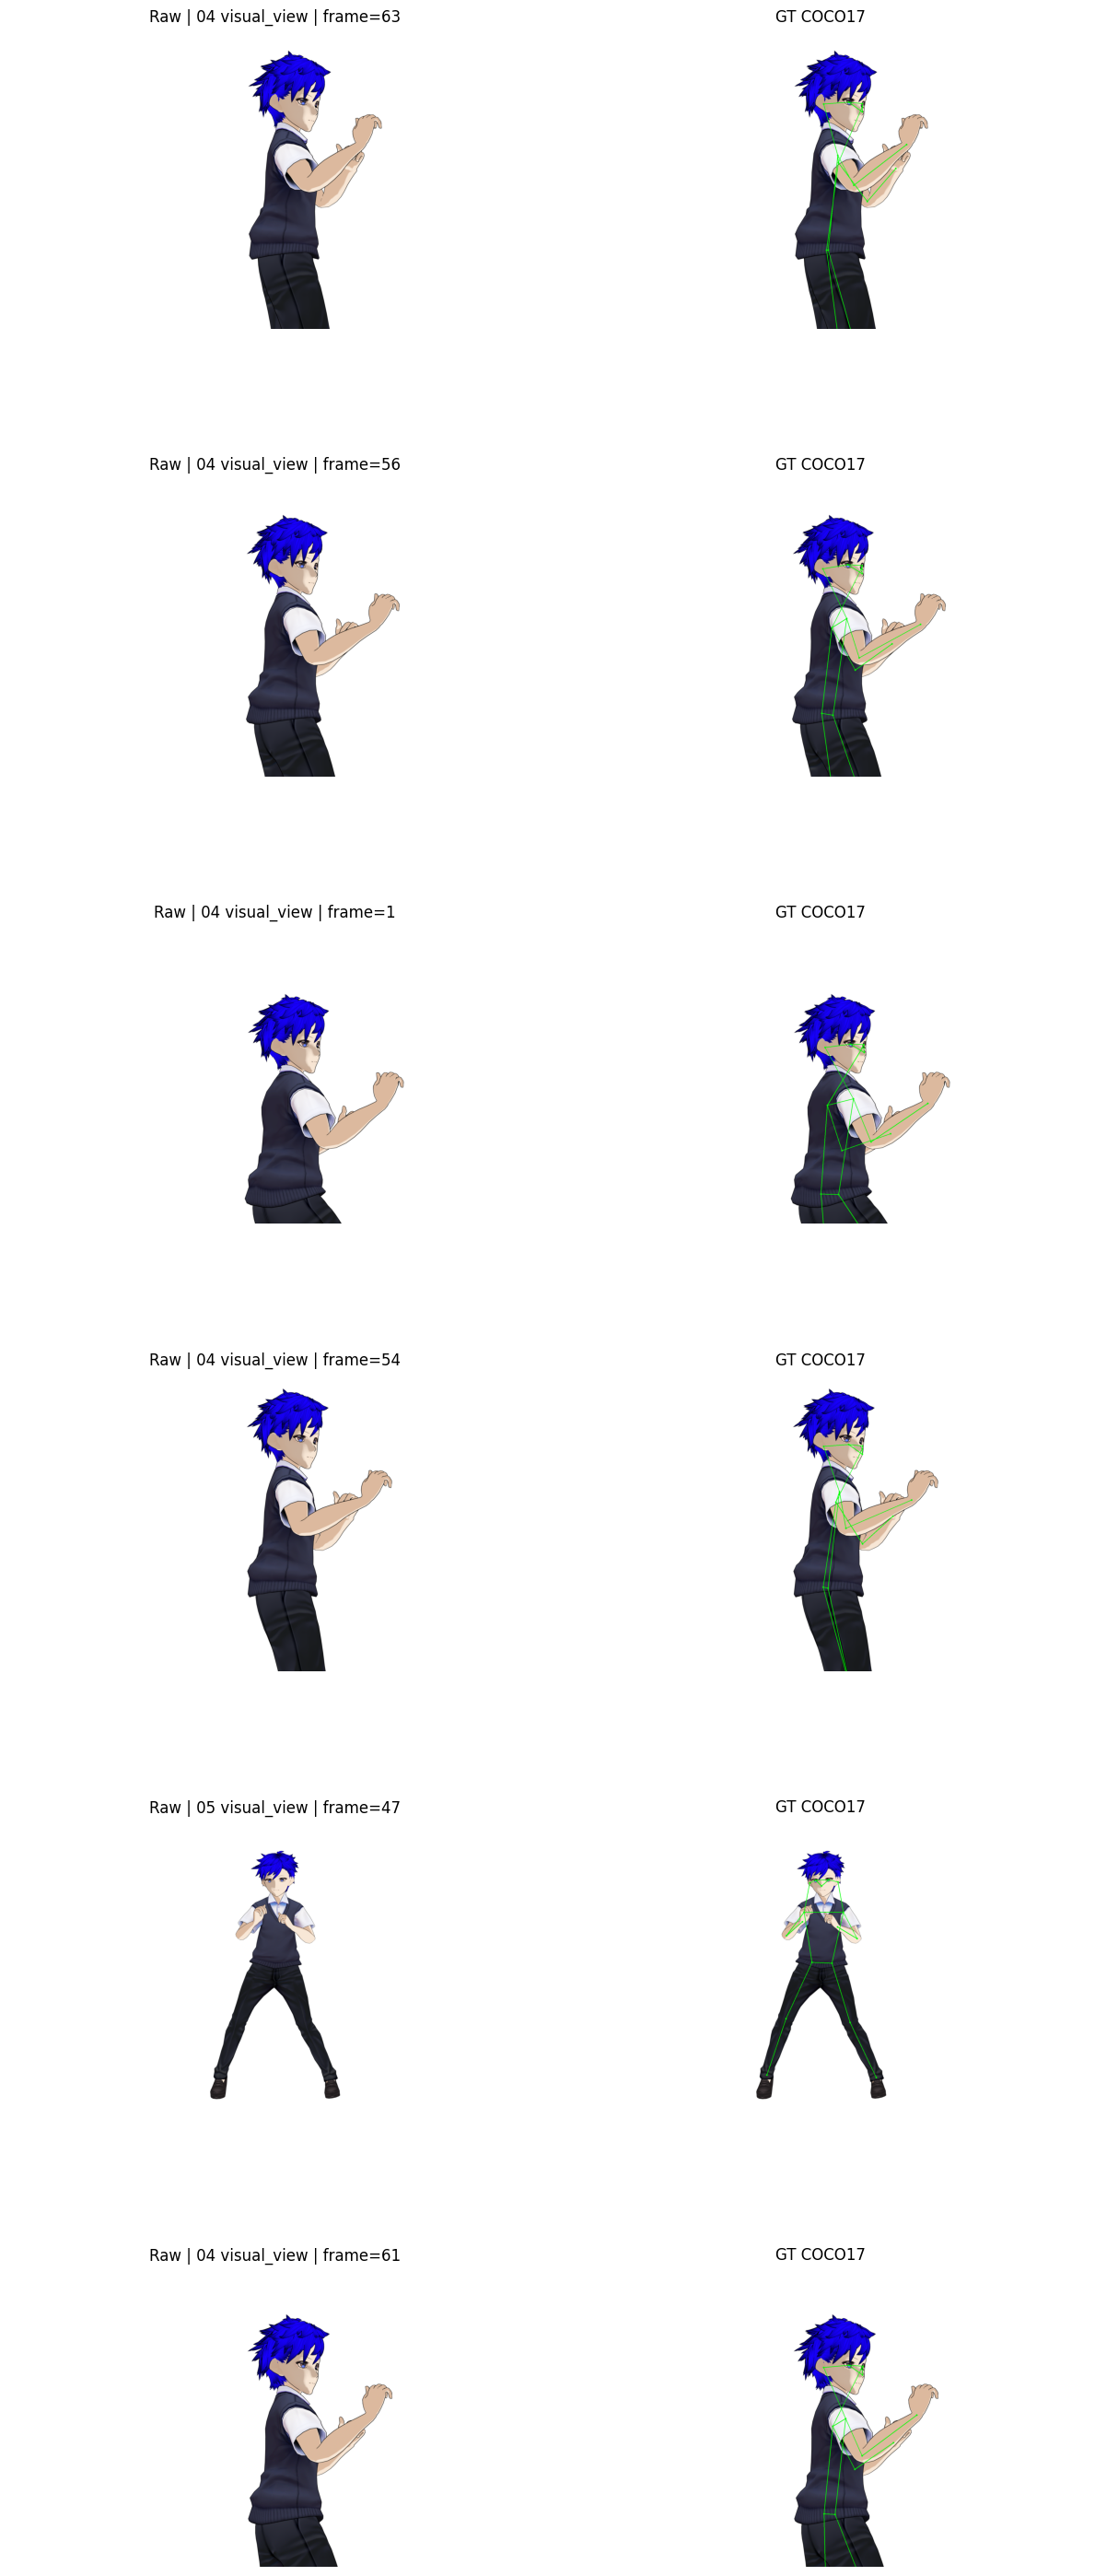

In [10]:

# ===== 8. 显示 GT 样本 =====
def draw_coco17(img, keypoints_xyv, color=(0,255,0), radius=4, line_thickness=2):
    canvas = img.copy()
    pts = np.array(keypoints_xyv, dtype=np.float32).reshape(-1, 3)
    for i, (x, y, v) in enumerate(pts):
        if v > 0:
            cv2.circle(canvas, (int(round(x)), int(round(y))), radius, color, -1)
    for a, b in COCO17_SKELETON:
        xa, ya, va = pts[a - 1]
        xb, yb, vb = pts[b - 1]
        if va > 0 and vb > 0:
            cv2.line(canvas, (int(round(xa)), int(round(ya))), (int(round(xb)), int(round(yb))), color, line_thickness)
    return canvas

sample_n = min(6, len(good_records))
samples = random.sample(good_records, sample_n)

fig, axes = plt.subplots(sample_n, 2, figsize=(12, 5 * sample_n))
if sample_n == 1:
    axes = np.array([axes])

for row, rec in enumerate(samples):
    img = cv2.imread(str(rec["img_path"]))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gt = draw_coco17(img_rgb, rec["keypoints_xyv"], color=(0,255,0))
    axes[row, 0].imshow(img_rgb)
    axes[row, 0].set_title(f"Raw | {rec['view_name']} | frame={rec['frame_id']}")
    axes[row, 0].axis("off")
    axes[row, 1].imshow(gt)
    axes[row, 1].set_title("GT COCO17")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

## 9. 转换为 COCO 标注

这一段会把你现在每个 frame 的 `coco17_strict1.json` 转成标准 COCO keypoint annotation：

- `images`
- `annotations`
- `categories`

并按 `view_name` 做分层拆分，尽量让 train / val 都覆盖不同视角。

In [11]:

# ===== 9. 生成 train / val 划分 =====
random.seed(42)

by_view = defaultdict(list)
for rec in good_records:
    by_view[rec["view_name"]].append(rec)

for k in by_view:
    by_view[k] = sorted(by_view[k], key=lambda r: r["frame_id"])

train_records, val_records = [], []
for view_name, recs in by_view.items():
    n = len(recs)
    n_val = max(1, int(round(n * 0.2)))
    idxs = set(np.linspace(0, n - 1, n_val, dtype=int).tolist())
    for i, rec in enumerate(recs):
        if i in idxs:
            val_records.append(rec)
        else:
            train_records.append(rec)

print("train:", len(train_records), "val:", len(val_records))

train: 290 val: 71


In [12]:

# ===== 10. 拷贝图像并生成 COCO JSON =====
def build_coco(records, split_name: str, dst_img_dir: Path):
    images = []
    annotations = []
    ann_id = 1

    for img_id, rec in enumerate(tqdm(records, desc=f"build {split_name}"), start=1):
        src = rec["img_path"]
        img = cv2.imread(str(src))
        h, w = img.shape[:2]

        dst_name = f"{rec['view_name'].replace(' ', '_')}_frame_{rec['frame_id']:04d}{src.suffix.lower()}"
        dst = dst_img_dir / dst_name
        if not dst.exists():
            shutil.copy2(src, dst)

        images.append({
            "id": img_id,
            "file_name": dst_name,
            "width": w,
            "height": h
        })

        annotations.append({
            "id": ann_id,
            "image_id": img_id,
            "category_id": 1,
            "iscrowd": 0,
            "num_keypoints": rec["num_keypoints"],
            "keypoints": [round(float(v), 4) if i % 3 != 2 else int(v) for i, v in enumerate(rec["keypoints_xyv"])],
            "bbox": [round(float(v), 4) for v in rec["bbox_xywh"]],
            "area": round(float(rec["area"]), 4)
        })
        ann_id += 1

    categories = [{
        "id": 1,
        "name": "person",
        "supercategory": "person",
        "keypoints": COCO17_NAMES,
        "skeleton": COCO17_SKELETON
    }]

    return {
        "info": {
            "description": "Mixamo / exported COCO17 strict1 converted to COCO keypoint format",
            "version": "1.0"
        },
        "licenses": [],
        "images": images,
        "annotations": annotations,
        "categories": categories
    }

train_coco = build_coco(train_records, "train", TRAIN_IMG_DIR)
val_coco = build_coco(val_records, "val", VAL_IMG_DIR)

train_json_path = ANN_ROOT / "train_coco17.json"
val_json_path = ANN_ROOT / "val_coco17.json"

train_json_path.write_text(json.dumps(train_coco, ensure_ascii=False, indent=2), encoding="utf-8")
val_json_path.write_text(json.dumps(val_coco, ensure_ascii=False, indent=2), encoding="utf-8")

print(train_json_path)
print(val_json_path)

build train:   0%|          | 0/290 [00:00<?, ?it/s]

libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng w

build val:   0%|          | 0/71 [00:00<?, ?it/s]

libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng w

/home/tvem/anime/AniPose/data/mixamo_coco17/annotations/train_coco17.json
/home/tvem/anime/AniPose/data/mixamo_coco17/annotations/val_coco17.json


libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate


In [13]:

# ===== 11. 快速查看 COCO JSON 内容 =====
print("train images =", len(train_coco["images"]))
print("train anns   =", len(train_coco["annotations"]))
print("val images   =", len(val_coco["images"]))
print("val anns     =", len(val_coco["annotations"]))

train_coco["annotations"][0]

train images = 290
train anns   = 290
val images   = 71
val anns     = 71


{'id': 1,
 'image_id': 1,
 'category_id': 1,
 'iscrowd': 0,
 'num_keypoints': 17,
 'keypoints': [1174.6085,
  662.7133,
  2,
  1199.2886,
  616.8789,
  2,
  1195.7628,
  616.8789,
  2,
  1296.2459,
  618.6418,
  2,
  1271.5659,
  620.4046,
  2,
  1420.1844,
  878.4964,
  2,
  1192.7638,
  853.3268,
  2,
  1408.1649,
  1104.2914,
  2,
  1078.9275,
  1015.4783,
  2,
  1122.3799,
  1015.7752,
  2,
  895.5418,
  878.8145,
  2,
  1388.4138,
  1259.6852,
  2,
  1260.6883,
  1237.3253,
  2,
  1443.1465,
  1766.2542,
  2,
  1011.4489,
  1663.4252,
  2,
  1769.3173,
  2130.5664,
  2,
  962.0318,
  2055.0498,
  2],
 'bbox': [869.2985, 571.4383, 926.2621, 1604.5688],
 'area': 1486251.1574}

## 10. DWPose 零样本效果展示（zero-shot）

这里先不训练，直接拿现成 DWPose 做推理，然后只保留前 17 个 body keypoints，与 COCO17 GT 做可视化对比。

> 说明：  
> - `rtmlib` 提供了 DWPose / RTMPose / RTMW / ViTPose 的轻量推理接口。  
> - DWPose 是 **whole-body 133 keypoints** 模型；COCO-WholeBody 的前 17 个 keypoints 对应 body17，因此这里直接取前 17 个与 GT 对齐。  
> - 这一步主要用于 **看零样本落点风格、偏差和可训练性**。

In [14]:

# ===== 12. DWPose 零样本推理 =====
# 如未安装，先执行：
# !pip install -U rtmlib onnxruntime opencv-python matplotlib

from rtmlib import Wholebody

device = "cuda"   # 可改成 "cpu" / "mps"
backend = "onnxruntime"

# Wholebody(mode='performance') 通常会优先选择较强的 whole-body 预训练模型；
# 在 rtmlib 当前实现里可直接用于 DWPose / RTMW 等整套解决方案。
wholebody = Wholebody(
    mode="performance",
    backend=backend,
    device=device,
    to_openpose=False
)

print("Zero-shot inferencer ready.")

/home/tvem/anaconda3/envs/anipose3/lib/python3.10/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
2026-03-19 03:06:08.559041663 [W:onnxruntime:, graph.cc:4885 CleanUnusedInitializersAndNodeArgs] Removing initializer '1701'. It is not used by any node and should be removed from the model.


load /home/tvem/.cache/rtmlib/hub/checkpoints/yolox_m_8xb8-300e_humanart-c2c7a14a.onnx with onnxruntime backend
load /home/tvem/.cache/rtmlib/hub/checkpoints/rtmw-dw-x-l_simcc-cocktail14_270e-384x288_20231122.onnx with onnxruntime backend
Zero-shot inferencer ready.


2026-03-19 03:06:08.559057957 [W:onnxruntime:, graph.cc:4885 CleanUnusedInitializersAndNodeArgs] Removing initializer '1706'. It is not used by any node and should be removed from the model.
2026-03-19 03:06:08.559091643 [W:onnxruntime:, graph.cc:4885 CleanUnusedInitializersAndNodeArgs] Removing initializer '1709'. It is not used by any node and should be removed from the model.


In [15]:

# ===== 13. 选择若干样本做 zero-shot 对比 =====
def select_main_person(keypoints, scores):
    # keypoints: [N, K, 2], scores: [N, K]
    # 如果图中有多人，取均分最高的一人
    if len(keypoints) == 0:
        return None, None
    mean_scores = scores.mean(axis=1)
    idx = int(np.argmax(mean_scores))
    return keypoints[idx], scores[idx]

def coco17_from_wholebody133(kpts133, sc133):
    # COCO-WholeBody 的 body 17 在前 17 个位置
    k17 = np.asarray(kpts133[:17], dtype=np.float32)
    s17 = np.asarray(sc133[:17], dtype=np.float32)
    return k17, s17

def xyv_from_pred17(k17, s17, thr=0.15):
    out = []
    for (x, y), s in zip(k17, s17):
        v = 2 if float(s) >= thr else 0
        out.extend([float(x), float(y), int(v)])
    return out

zero_shot_samples = random.sample(good_records, min(6, len(good_records)))
len(zero_shot_samples)

6

  0%|          | 0/6 [00:00<?, ?it/s]

libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate


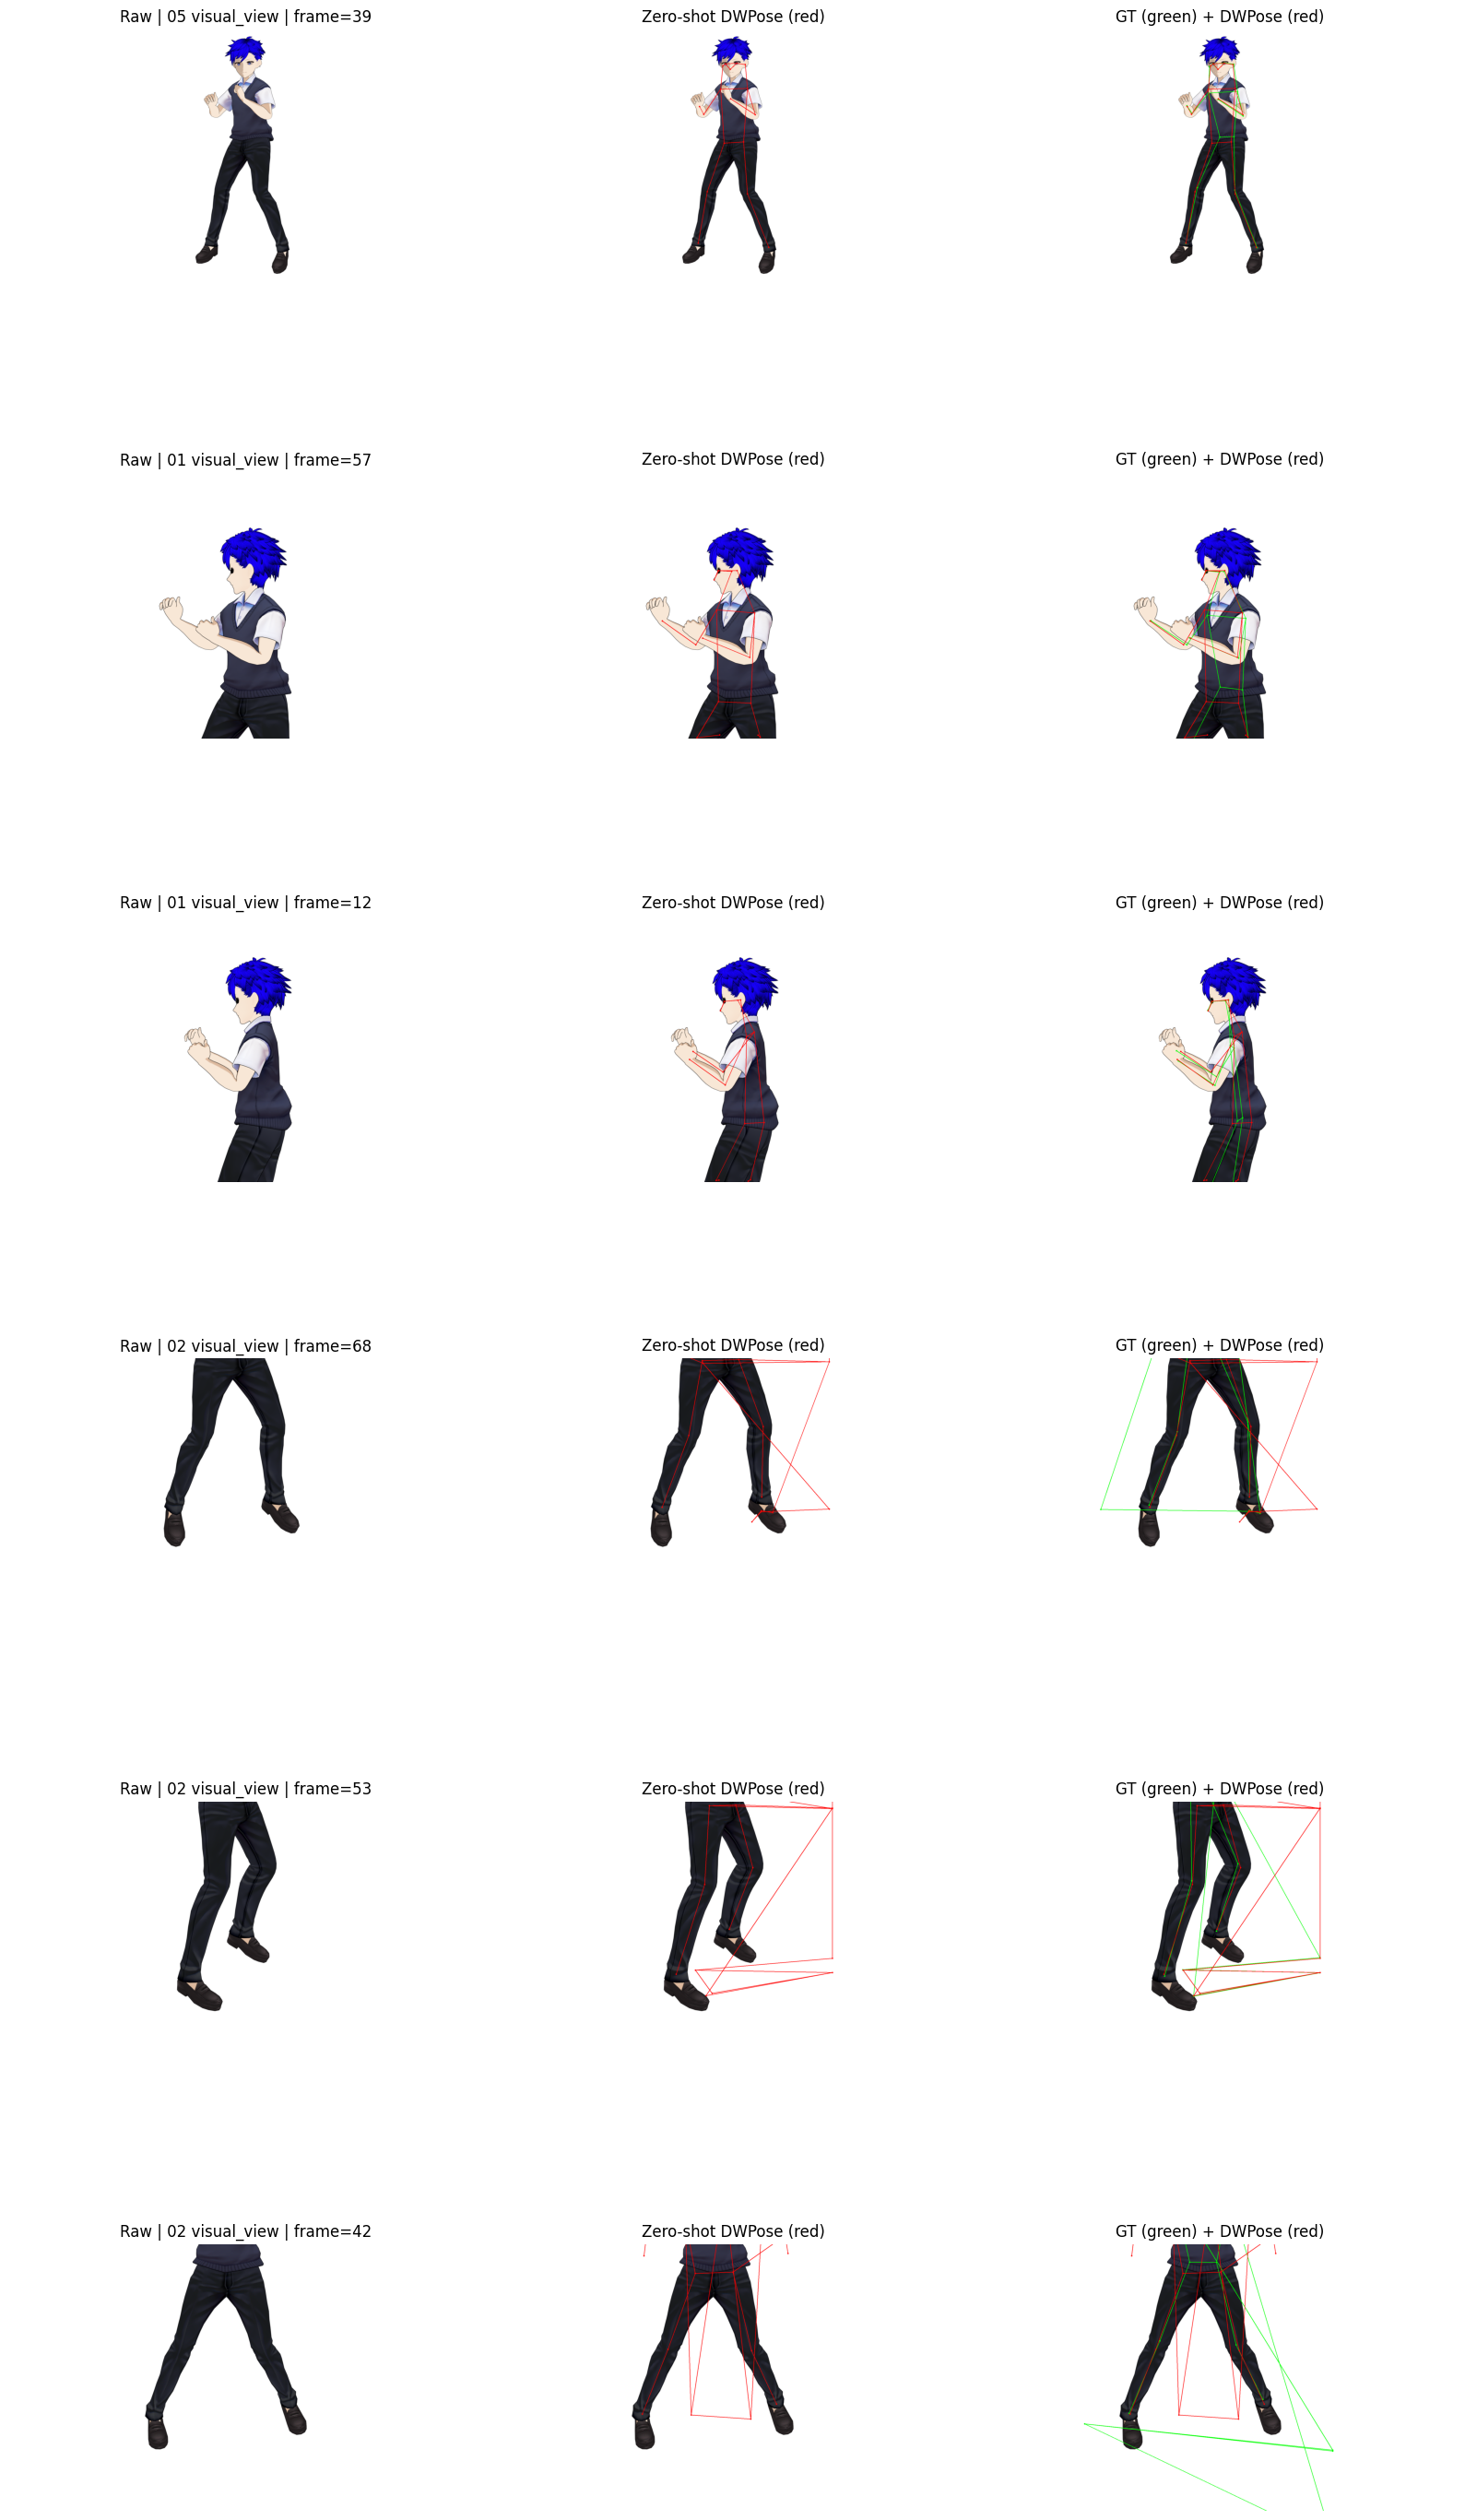

In [16]:

# ===== 14. zero-shot 可视化 =====
fig, axes = plt.subplots(len(zero_shot_samples), 3, figsize=(16, 5 * len(zero_shot_samples)))
if len(zero_shot_samples) == 1:
    axes = np.array([axes])

for row, rec in enumerate(tqdm(zero_shot_samples)):
    img_bgr = cv2.imread(str(rec["img_path"]))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    pred_kpts, pred_scores = wholebody(img_bgr)
    pred_one, score_one = select_main_person(pred_kpts, pred_scores)

    if pred_one is not None:
        pred17, score17 = coco17_from_wholebody133(pred_one, score_one)
        pred_xyv = xyv_from_pred17(pred17, score17, thr=0.15)
        pred_vis = draw_coco17(img_rgb, pred_xyv, color=(255, 0, 0))
    else:
        pred_xyv = None
        pred_vis = img_rgb.copy()

    gt_vis = draw_coco17(img_rgb, rec["keypoints_xyv"], color=(0,255,0))
    mix_vis = gt_vis.copy()
    if pred_xyv is not None:
        mix_vis = draw_coco17(mix_vis, pred_xyv, color=(255,0,0))

    axes[row, 0].imshow(img_rgb)
    axes[row, 0].set_title(f"Raw | {rec['view_name']} | frame={rec['frame_id']}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(pred_vis)
    axes[row, 1].set_title("Zero-shot DWPose (red)")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(mix_vis)
    axes[row, 2].set_title("GT (green) + DWPose (red)")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

In [17]:

# ===== 15. 简单数值指标：零样本 PCK@0.2（相对 GT bbox 较长边） =====
def pck_single(gt_xyv, pred_xyv, thr_ratio=0.2):
    gt = np.array(gt_xyv, dtype=np.float32).reshape(-1, 3)
    pr = np.array(pred_xyv, dtype=np.float32).reshape(-1, 3)
    visible = gt[:, 2] > 0
    if visible.sum() == 0:
        return np.nan

    xs = gt[visible, 0]
    ys = gt[visible, 1]
    scale = max(xs.max() - xs.min(), ys.max() - ys.min(), 1.0)
    thr = thr_ratio * scale

    d = np.sqrt(((gt[:, :2] - pr[:, :2]) ** 2).sum(axis=1))
    ok = (d <= thr) & visible
    return ok.sum() / visible.sum()

pcks = []
for rec in tqdm(good_records):
    img_bgr = cv2.imread(str(rec["img_path"]))
    pred_kpts, pred_scores = wholebody(img_bgr)
    pred_one, score_one = select_main_person(pred_kpts, pred_scores)
    if pred_one is None:
        continue
    pred17, score17 = coco17_from_wholebody133(pred_one, score_one)
    pred_xyv = xyv_from_pred17(pred17, score17, thr=0.15)
    pcks.append(pck_single(rec["keypoints_xyv"], pred_xyv, thr_ratio=0.2))

print("Zero-shot PCK@0.2 =", float(np.nanmean(pcks)))

  0%|          | 0/361 [00:00<?, ?it/s]

libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng w

Zero-shot PCK@0.2 = 0.8859377546032264


## 11. 生成 RTMPose 微调配置

下面开始正式微调。

训练策略：

- 任务：**top-down 2D body pose estimation**
- 关键点：**COCO17**
- 数据集：刚刚转换出的 COCO 风格 `train_coco17.json / val_coco17.json`
- 模型：推荐从 **RTMPose-m 256x192** 或 **RTMPose-s 256x192** 开始
- 训练入口：`mmpose/tools/train.py`

> 为什么这里用 RTMPose/MMPose 训练，而不是直接用 rtmlib？  
> 因为 `rtmlib` 当前主打推理，不是完整训练框架；MMPose 才是官方训练/微调主入口。

In [18]:

# ===== 16. 准备 mmpose 仓库路径 =====
MMPose_ROOT = PROJECT_ROOT / "mmpose"
assert MMPose_ROOT.exists(), "请先在 PROJECT_ROOT 下 clone mmpose 仓库：git clone https://github.com/open-mmlab/mmpose.git"

print(MMPose_ROOT)

/home/tvem/anime/AniPose/mmpose


In [19]:

# ===== 17. 生成 custom dataset_info（COCO17） =====
dataset_info_py = WORK_ROOT / "mixamo_coco17_dataset_info.py"

dataset_info_content = '''
dataset_info = dict(
    dataset_name='mixamo_coco17',
    paper_info=dict(
        author='OpenAI notebook generator',
        title='Mixamo COCO17 custom pose dataset',
        container='local',
        year='2026',
        homepage='',
    ),
    keypoint_info={
        0: dict(name='nose', id=0, color=[51, 153, 255], type='upper', swap=''),
        1: dict(name='left_eye', id=1, color=[51, 153, 255], type='upper', swap='right_eye'),
        2: dict(name='right_eye', id=2, color=[51, 153, 255], type='upper', swap='left_eye'),
        3: dict(name='left_ear', id=3, color=[51, 153, 255], type='upper', swap='right_ear'),
        4: dict(name='right_ear', id=4, color=[51, 153, 255], type='upper', swap='left_ear'),
        5: dict(name='left_shoulder', id=5, color=[0, 255, 0], type='upper', swap='right_shoulder'),
        6: dict(name='right_shoulder', id=6, color=[255, 128, 0], type='upper', swap='left_shoulder'),
        7: dict(name='left_elbow', id=7, color=[0, 255, 0], type='upper', swap='right_elbow'),
        8: dict(name='right_elbow', id=8, color=[255, 128, 0], type='upper', swap='left_elbow'),
        9: dict(name='left_wrist', id=9, color=[0, 255, 0], type='upper', swap='right_wrist'),
        10: dict(name='right_wrist', id=10, color=[255, 128, 0], type='upper', swap='left_wrist'),
        11: dict(name='left_hip', id=11, color=[0, 255, 0], type='lower', swap='right_hip'),
        12: dict(name='right_hip', id=12, color=[255, 128, 0], type='lower', swap='left_hip'),
        13: dict(name='left_knee', id=13, color=[0, 255, 0], type='lower', swap='right_knee'),
        14: dict(name='right_knee', id=14, color=[255, 128, 0], type='lower', swap='left_knee'),
        15: dict(name='left_ankle', id=15, color=[0, 255, 0], type='lower', swap='right_ankle'),
        16: dict(name='right_ankle', id=16, color=[255, 128, 0], type='lower', swap='left_ankle'),
    },
    skeleton_info={
        0: dict(link=('left_ankle', 'left_knee'), id=0, color=[0, 255, 0]),
        1: dict(link=('left_knee', 'left_hip'), id=1, color=[0, 255, 0]),
        2: dict(link=('right_ankle', 'right_knee'), id=2, color=[255, 128, 0]),
        3: dict(link=('right_knee', 'right_hip'), id=3, color=[255, 128, 0]),
        4: dict(link=('left_hip', 'right_hip'), id=4, color=[51, 153, 255]),
        5: dict(link=('left_shoulder', 'left_hip'), id=5, color=[0, 255, 0]),
        6: dict(link=('right_shoulder', 'right_hip'), id=6, color=[255, 128, 0]),
        7: dict(link=('left_shoulder', 'right_shoulder'), id=7, color=[51, 153, 255]),
        8: dict(link=('left_shoulder', 'left_elbow'), id=8, color=[0, 255, 0]),
        9: dict(link=('right_shoulder', 'right_elbow'), id=9, color=[255, 128, 0]),
        10: dict(link=('left_elbow', 'left_wrist'), id=10, color=[0, 255, 0]),
        11: dict(link=('right_elbow', 'right_wrist'), id=11, color=[255, 128, 0]),
        12: dict(link=('nose', 'left_eye'), id=12, color=[51, 153, 255]),
        13: dict(link=('nose', 'right_eye'), id=13, color=[51, 153, 255]),
        14: dict(link=('left_eye', 'left_ear'), id=14, color=[51, 153, 255]),
        15: dict(link=('right_eye', 'right_ear'), id=15, color=[51, 153, 255]),
        16: dict(link=('left_ear', 'left_shoulder'), id=16, color=[51, 153, 255]),
        17: dict(link=('right_ear', 'right_shoulder'), id=17, color=[51, 153, 255]),
    },
    joint_weights=[1.] * 17,
    sigmas=[0.026, 0.025, 0.025, 0.035, 0.035, 0.079, 0.079, 0.072, 0.072,
            0.062, 0.062, 0.107, 0.107, 0.087, 0.087, 0.089, 0.089]
)
'''
dataset_info_py.write_text(dataset_info_content.strip() + "\n", encoding="utf-8")
print(dataset_info_py)

/home/tvem/anime/AniPose/work_dirs/mixamo_dwpose_rtmpose_coco17/mixamo_coco17_dataset_info.py


In [20]:

# ===== 18. 生成 RTMPose 微调 config =====
# 推荐从官方 body17 / coco 预训练继续微调
# 如果你想更轻量，可把 rtmpose-m 改成 rtmpose-s 或 rtmpose-t

config_py = WORK_ROOT / "rtmpose_mixamo_coco17_finetune.py"

config_content = f'''
_base_ = ['{(MMPose_ROOT / "configs/body_2d_keypoint/rtmpose/coco/rtmpose-m_8xb256-420e_coco-256x192.py").as_posix()}']

custom_imports = dict(imports=[], allow_failed_imports=False)

train_cfg = dict(max_epochs=60, val_interval=5)

default_hooks = dict(
    checkpoint=dict(save_best='coco/AP', rule='greater', interval=5, max_keep_ckpts=3)
)

optim_wrapper = dict(
    optimizer=dict(lr=2e-4),
)

# 数据集
dataset_type = 'CocoDataset'
data_mode = 'topdown'
data_root = '{DATA_ROOT.as_posix()}'

metainfo = dict(from_file='{dataset_info_py.as_posix()}')

train_dataloader = dict(
    batch_size=32,
    num_workers=4,
    persistent_workers=True,
    dataset=dict(
        type=dataset_type,
        data_root=data_root,
        data_mode=data_mode,
        ann_file='annotations/train_coco17.json',
        data_prefix=dict(img='train/images/'),
        metainfo=metainfo,
    )
)

val_dataloader = dict(
    batch_size=16,
    num_workers=2,
    persistent_workers=True,
    drop_last=False,
    dataset=dict(
        type=dataset_type,
        data_root=data_root,
        data_mode=data_mode,
        ann_file='annotations/val_coco17.json',
        data_prefix=dict(img='val/images/'),
        test_mode=True,
        metainfo=metainfo,
    )
)

test_dataloader = val_dataloader

val_evaluator = dict(
    type='CocoMetric',
    ann_file='{val_json_path.as_posix()}'
)
test_evaluator = val_evaluator

# 如果数据量不大，适度减弱增强更稳
train_pipeline = [
    dict(type='LoadImage'),
    dict(type='GetBBoxCenterScale'),
    dict(type='RandomFlip', direction='horizontal'),
    dict(type='RandomHalfBody'),
    dict(type='RandomBBoxTransform', scale_factor=[0.6, 1.4], rotate_factor=60),
    dict(type='TopdownAffine', input_size=_base_.codec['input_size']),
    dict(type='GenerateTarget', encoder=_base_.codec),
    dict(type='PackPoseInputs')
]

val_pipeline = [
    dict(type='LoadImage'),
    dict(type='GetBBoxCenterScale'),
    dict(type='TopdownAffine', input_size=_base_.codec['input_size']),
    dict(type='PackPoseInputs')
]

auto_scale_lr = dict(base_batch_size=256)
'''
config_py.write_text(config_content.strip() + "\n", encoding="utf-8")
print(config_py)
print(config_py.read_text(encoding="utf-8")[:1500])

/home/tvem/anime/AniPose/work_dirs/mixamo_dwpose_rtmpose_coco17/rtmpose_mixamo_coco17_finetune.py
_base_ = ['/home/tvem/anime/AniPose/mmpose/configs/body_2d_keypoint/rtmpose/coco/rtmpose-m_8xb256-420e_coco-256x192.py']

custom_imports = dict(imports=[], allow_failed_imports=False)

train_cfg = dict(max_epochs=60, val_interval=5)

default_hooks = dict(
    checkpoint=dict(save_best='coco/AP', rule='greater', interval=5, max_keep_ckpts=3)
)

optim_wrapper = dict(
    optimizer=dict(lr=2e-4),
)

# 数据集
dataset_type = 'CocoDataset'
data_mode = 'topdown'
data_root = '/home/tvem/anime/AniPose/data/mixamo_coco17'

metainfo = dict(from_file='/home/tvem/anime/AniPose/work_dirs/mixamo_dwpose_rtmpose_coco17/mixamo_coco17_dataset_info.py')

train_dataloader = dict(
    batch_size=32,
    num_workers=4,
    persistent_workers=True,
    dataset=dict(
        type=dataset_type,
        data_root=data_root,
        data_mode=data_mode,
        ann_file='annotations/train_coco17.json',
        data_pref

In [21]:

# ===== 19. 可视化数据浏览（训练前非常建议跑一次） =====
# 这一步能快速检查你的 bbox / keypoints / affine 是否正常
# 需要 mmpose 源码仓库里自带的 browse_dataset.py

browse_script = MMPose_ROOT / "tools" / "misc" / "browse_dataset.py"
print("browse script exists:", browse_script.exists())
print("command:")
print(f"python {browse_script} {config_py} --output-dir {VIS_ROOT / 'browse'} --phase train")

browse script exists: True
command:
python /home/tvem/anime/AniPose/mmpose/tools/misc/browse_dataset.py /home/tvem/anime/AniPose/work_dirs/mixamo_dwpose_rtmpose_coco17/rtmpose_mixamo_coco17_finetune.py --output-dir /home/tvem/anime/AniPose/work_dirs/mixamo_dwpose_rtmpose_coco17/vis/browse --phase train


In [22]:

# ===== 20. 启动微调 =====
# 单卡训练示例：
# !python {MMPose_ROOT / 'tools/train.py'} {config_py}

# 指定 work_dir：
!python {MMPose_ROOT / 'tools/train.py'} {config_py} --work-dir {WORK_ROOT}

# 多卡训练示例（Linux）：
# !bash {MMPose_ROOT / 'tools/dist_train.sh'} {config_py} 2 --work-dir {WORK_ROOT}

print("Ready to train.")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/home/tvem/anime/AniPose/mmpose/tools/train.py", line 7, in <module>
    from mmengine.runner import Runner
  File "/home/tvem/anaconda3/envs/anipose3/lib/python3.10/site-packages/mmengine/runner/__init__.py", line 2, in <module>
    from ._flexible_runner import FlexibleRunner
  File "/home/tvem/anaconda3/envs/anipose3/lib/python3.10/site-packages/mmengine/runner/_flexible_runner.py", line 10, in <module>
    import torch.nn as nn
  File "/home/tvem/anaconda3/envs/anipose3/lib/python3.10/site-packages/torch/__init

In [23]:

# ===== 21. 训练后评估 =====
# best 权重通常会保存在 WORK_ROOT 下，例如 best_coco_AP_epoch_XX.pth
!python {MMPose_ROOT / 'tools/test.py'} {config_py} {WORK_ROOT / 'best_coco_AP_epoch_XX.pth'}

print("训练完成后把 best checkpoint 文件名改掉再运行。")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/home/tvem/anime/AniPose/mmpose/tools/test.py", line 8, in <module>
    from mmengine.hooks import Hook
  File "/home/tvem/anaconda3/envs/anipose3/lib/python3.10/site-packages/mmengine/hooks/__init__.py", line 2, in <module>
    from .checkpoint_hook import CheckpointHook
  File "/home/tvem/anaconda3/envs/anipose3/lib/python3.10/site-packages/mmengine/hooks/checkpoint_hook.py", line 11, in <module>
    from mmengine.dist import is_main_process, master_only
  File "/home/tvem/anaconda3/envs/anipose3/lib/python3.10/s

## 12. 微调后可视化对比

你可以把：

- **零样本 DWPose**
- **微调前 RTMPose 预训练模型**
- **微调后 checkpoint**

放到同一批样本上做可视化对比。

下面给出一个最实用的推理脚本模板：直接读取 COCO val 图像和 bbox，跑 top-down 预测，再与 GT 叠加。

In [24]:

# ===== 22. 微调后 checkpoint 推理（MMPose inferencer 方式） =====
# 这一段会在你训练完成后使用 checkpoint 做验证集可视化

# from mmpose.apis import MMPoseInferencer
# inferencer = MMPoseInferencer(
#     pose2d=str(config_py),
#     pose2d_weights=str(WORK_ROOT / 'best_coco_AP_epoch_XX.pth'),
#     device='cuda:0'
# )
#
# results = inferencer(
#     inputs=str(VAL_IMG_DIR),
#     show=False,
#     out_dir=str(VIS_ROOT / 'finetuned_pred')
# )

print("训练完成后取消注释并填入 checkpoint 路径。")

训练完成后取消注释并填入 checkpoint 路径。


In [25]:

# ===== 23. 一个更直接的对比：读取 val 标注，叠加 GT 和预测 =====
# 如果你想严格按 val_coco17.json 里的 bbox 来跑 top-down 推理，可以继续扩展这里。
# 我先保留成模板，等你下一步要“RTMPose 微调 notebook”时，我可以继续给你做第二份更完整的评估 notebook。

print("Notebook 核心流程已生成。")

Notebook 核心流程已生成。


## 13. 你接下来最常改的只有这几处

1. `PROJECT_ROOT`
2. `device = "cuda"`
3. `rtmpose-m` 改成 `rtmpose-s / rtmpose-t`
4. `max_epochs`
5. `batch_size`
6. 是否启用更激进的数据增强

---

如果你下一步要，我建议直接再做第二个 notebook：

- **RTMPose 纯训练版 notebook**
- **包含训练曲线、best checkpoint 自动查找、验证集定量表格、误差热图、可视化导出**

这个 notebook 先满足你当前要求：  
**DWPose 零样本展示 + 按 COCO17 转 COCO annotation + 用 RTMPose/MMPose 接口微调。**